In [2]:
import os
import json
import ast
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from huggingface_hub import hf_hub_download
import requests

embedder = SentenceTransformer("all-MiniLM-L6-v2")
print("SBERT loaded.")

# ── reproducibility seeds ────────────────────────────────────────────────────
GLOBAL_SEED = 42
os.environ['PYTHONHASHSEED'] = str(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# ── sampling constants ───────────────────────────────────────────────────────
N_SAMPLES   = 50       # samples per split (20 train + 20 test = 40 total)
SAMPLE_SIZE = 1_000    # rows per sample

# ── generic schema columns (written by every generalize_* function) ─────────
# text_fidelity_e (T12e baseline) is always '' by definition and is NOT stored —
# downstream code should use '' directly for T12e rather than reading a column.
GENERIC_COLS = [
    "primary_id", "secondary_id", "aggregate_id",
    "text_fidelity_a", "text_fidelity_b",
    "categorical_label", "scalar_label", "structural_edges",
]

# accumulates rows for the final schema_mapping.csv
SCHEMA_MAPPING_ROWS = []

def log_mapping(dataset, generic_key, original_keys, notes=""):
    SCHEMA_MAPPING_ROWS.append({
        "dataset": dataset,
        "generic_key": generic_key,
        "original_key(s)": original_keys,
        "notes": notes,
    })

def print_fidelity_sample(df, n=2):
    """Print T12a/T12b in full (no truncation) for the first n rows."""
    for i in range(min(n, len(df))):
        row = df.iloc[i]
        print(f"\n[{i}] primary_id = {row['primary_id']}")
        print(f"    T12b: {row['text_fidelity_b']}")
        print(f"    T12a: {row['text_fidelity_a']}")

# ── shared helpers ──────────────────────────────────────────────────────────
AUTHOR_COL = 'authors_parsed'

def parse_authors_field(val):
    if isinstance(val, list): return val
    if isinstance(val, str):
        for parser in (ast.literal_eval, json.loads):
            try:
                parsed = parser(val)
                if isinstance(parsed, list): return parsed
            except Exception: continue
    return []

def handle_author(a):
    try:
        first = a[1].strip() if len(a) > 1 else ''
        last  = a[0].strip() if len(a) > 0 else ''
        return f"{first}|{last}"
    except Exception: return ""

def top_level_category(cats):
    """ArXiv categories field, e.g. 'cond-mat.str-el cond-mat.stat-mech' -> 'cond-mat'"""
    if not isinstance(cats, str) or not cats.strip():
        return None
    first = cats.split()[0]
    return first.split(".")[0]

def parse_price(p):
    """'$99.20' -> 99.20 ; handles missing/odd values gracefully."""
    if isinstance(p, (int, float)):
        return float(p)
    if isinstance(p, str):
        cleaned = re.sub(r"[^0-9.]", "", p)
        try:
            return float(cleaned) if cleaned else None
        except Exception:
            return None
    return None

def parse_list_field(val):
    """Stringified list (e.g. History's 'neighbour' column) -> Python list."""
    if isinstance(val, list): return val
    if isinstance(val, str):
        try:
            parsed = ast.literal_eval(val)
            if isinstance(parsed, list): return parsed
        except Exception:
            pass
    return []

def split_description_title(raw_text):
    """History 'text' field is formatted 'Description: ...; Title: ...'.
    Returns (description, title). Falls back to (raw_text, '') if the
    pattern isn't found, so text_fidelity_b degrades gracefully to the
    full field rather than failing.
    """
    if not isinstance(raw_text, str):
        return '', ''
    m = re.match(r'^Description:\s*(.*?);\s*Title:\s*(.*)$', raw_text, re.DOTALL)
    if m:
        return m.group(1).strip(), m.group(2).strip()
    return raw_text.strip(), ''

def makedirs_split(dataset):
    for split in ["train", "test"]:
        os.makedirs(f"{dataset}/{split}/embeddings", exist_ok=True)
        os.makedirs(f"{dataset}/{split}/samples",    exist_ok=True)

def generate_canonical_samples(df, dataset, split_name,
                                n_samples=N_SAMPLES, sample_size=SAMPLE_SIZE):
    """Save n_samples x sample_size-row JSONL subsets drawn from df (generic schema).
    Seed = sample index for reproducibility across datasets.
    """
    base = f"{dataset}/{split_name}/samples"
    os.makedirs(base, exist_ok=True)
    for i in range(n_samples):
        sample = df.sample(
            n=min(sample_size, len(df)),
            random_state=i
        ).reset_index(drop=True)
        sample.to_json(f"{base}/sample_{i:02d}.jsonl", orient="records", lines=True)
    print(f"✅ {dataset}/{split_name}/samples : {n_samples} × {sample_size:,} rows")

def compute_aggregate_embeddings(embs, groups, emb_base, name):
    """Mean-pool row embeddings by group key (for N9 aggregate entity nodes).
    embs   : (n_rows, dim) array
    groups : list/array of length n_rows giving each row's group key
    Saves {name}_embeddings.npy (n_groups, dim) and {name}_index.json (group keys, in order).
    """
    sums   = defaultdict(lambda: np.zeros(embs.shape[1]))
    counts = defaultdict(int)
    for emb, g in zip(embs, groups):
        if g is None or (isinstance(g, float) and np.isnan(g)):
            continue
        sums[g]   += emb
        counts[g] += 1

    keys     = list(sums.keys())
    agg_embs = np.vstack([sums[k] / counts[k] for k in keys]) if keys else np.zeros((0, embs.shape[1]))

    np.save(f"{emb_base}/{name}_embeddings.npy", agg_embs)
    with open(f"{emb_base}/{name}_index.json", "w") as f:
        json.dump([str(k) for k in keys], f)

    print(f"   {name}_embeddings  : {agg_embs.shape}  ({len(keys)} groups)")
    return agg_embs, keys

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

SBERT loaded.


<h4 style="font-family: 'Times New Roman', Times, serif; font-weight: bold;">========= &nbsp;&nbsp;&nbsp; DATASET 1/5 &nbsp;|&nbsp; ARXIV &nbsp;&nbsp;&nbsp; =========</h4>

In [10]:
N_ROWS = 100_000
# Path to the arXiv metadata snapshot (kaggle.com/datasets/Cornell-University/arxiv).
json_path = os.environ.get("ARXIV_SNAPSHOT", "arxiv-metadata-oai-snapshot.json")

if not os.path.exists(json_path):
    raise FileNotFoundError(f"Not found: {json_path}")

print(f"Reading {N_ROWS:,} rows...")
subset_df = pd.read_json(json_path, lines=True, nrows=N_ROWS)
print("Shape:", subset_df.shape)
print(subset_df[["id", "title", "categories"]].head(3))

arxiv_train_raw = subset_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
arxiv_test_raw  = subset_df.drop(arxiv_train_raw.index.tolist()).reset_index(drop=True)

makedirs_split("arxiv")
print(f"Train: {len(arxiv_train_raw):,} | Test: {len(arxiv_test_raw):,}")

Reading 100,000 rows...
Shape: (100000, 14)
         id                                              title      categories
0  704.0001  Calculation of prompt diphoton production cros...          hep-ph
1  704.0002           Sparsity-certifying Graph Decompositions   math.CO cs.CG
2  704.0003  The evolution of the Earth-Moon system based o...  physics.gen-ph
Train: 50,000 | Test: 50,000


In [11]:
def generalize_arxiv(df, log=False):
    """Rename ArXiv columns to the generic schema and precompute text fidelity strings."""
    df = df.copy()
    df[AUTHOR_COL] = df[AUTHOR_COL].apply(parse_authors_field)

    df['primary_id']   = df['id']
    df['secondary_id'] = df[AUTHOR_COL].apply(
        lambda al: [handle_author(a) for a in al if handle_author(a)]
    )
    df['aggregate_id'] = df['categories'].apply(top_level_category)

    title    = df['title'].fillna('')
    abstract = df['abstract'].fillna('')

    # T12b standard = entity's own name/title only
    df['text_fidelity_b'] = title.str.strip()
    # T12a contextual = title + primary content (abstract)
    df['text_fidelity_a'] = (title + ' ' + abstract).str.strip()

    df['categorical_label'] = df['aggregate_id']        # M1: top-level category
    df['scalar_label']      = None                        # M2: centrality composite, computed downstream from constructed graph
    df['structural_edges']  = None                        # ArXiv has no pre-given edge list

    if log:
        log_mapping("arxiv", "primary_id",        "id",             "paper identifier")
        log_mapping("arxiv", "secondary_id",      "authors_parsed", "list of 'First|Last' author strings (N8)")
        log_mapping("arxiv", "aggregate_id",      "categories",     "top-level category, e.g. 'cond-mat' (N9)")
        log_mapping("arxiv", "text_fidelity_a",   "title, abstract", "T12a contextual: title + abstract (entity name + primary content)")
        log_mapping("arxiv", "text_fidelity_b",   "title",           "T12b standard: title only (entity's own name/identifier)")
        log_mapping("arxiv", "text_fidelity_e",   "(none)",          "T12e baseline: empty string '' (not stored)")
        log_mapping("arxiv", "categorical_label", "categories",      "M1/M3: top-level category (same as aggregate_id)")
        log_mapping("arxiv", "scalar_label",      "(derived)",       "M2/M4: centrality composite, computed at TAG construction time")
        log_mapping("arxiv", "structural_edges",  "(none)",          "not available for ArXiv")

    return df[GENERIC_COLS]

arxiv_train = generalize_arxiv(arxiv_train_raw, log=True)
arxiv_test  = generalize_arxiv(arxiv_test_raw,  log=False)

arxiv_train.to_json("arxiv/train/raw.jsonl", orient="records", lines=True)
arxiv_test.to_json( "arxiv/test/raw.jsonl",  orient="records", lines=True)

print_fidelity_sample(arxiv_train)


[0] primary_id = 807.4728
    T12b: On the dynamics of thin shells of counter rotating particles
    T12a: On the dynamics of thin shells of counter rotating particles   In this paper we study the dynamics of self gravitating spherically symmetric
thin shells of counter rotating particles. We consider all possible velocity
distributions for the particles, and show that the equations of motion by
themselves do not constrain this distribution. We therefore consider the
dynamical stability of the resulting configurations under several possible
processes. This include the stability of static configurations as a whole,
where we find a lower bound for the compactness of the shells. We analyze also
the stability of the single particle orbits, and find conditions for "single
particle evaporation". Finally, in the case of a shell with particles whose
angular momenta are restricted to two values, we consider the conditions for
stability under splitting into two separate shells. This analysis le

In [12]:
def process_and_save_arxiv(df, split_name):
    base     = f"arxiv/{split_name}"
    emb_base = f"{base}/embeddings"

    n_authors = df['secondary_id'].apply(len)
    print(f"\n{split_name} — author counts:\n", n_authors.describe())

    author_sums   = defaultdict(lambda: np.zeros(384))
    author_counts = defaultdict(int)
    article_embs            = np.zeros((len(df), 384))  # T12b standard
    article_embs_contextual = np.zeros((len(df), 384))  # T12a contextual

    for i, row in enumerate(tqdm(df.itertuples(index=False), total=len(df), desc=split_name)):
        emb     = embedder.encode(row.text_fidelity_b, show_progress_bar=False)
        emb_ctx = embedder.encode(row.text_fidelity_a, show_progress_bar=False)
        article_embs[i]            = emb
        article_embs_contextual[i] = emb_ctx

        for aid in row.secondary_id:
            author_sums[aid]   += emb
            author_counts[aid] += 1

    author_list = list(author_sums.keys())
    author_embs = np.vstack([author_sums[a] / author_counts[a] for a in author_list]) if author_list else np.zeros((0, 384))

    # N7 embeddings — T12b standard and T12a contextual
    np.save(f"{emb_base}/article_embeddings.npy",            article_embs)
    np.save(f"{emb_base}/article_embeddings_contextual.npy", article_embs_contextual)

    # N8 author embeddings
    np.save(f"{emb_base}/author_embeddings.npy",  author_embs)
    with open(f"{emb_base}/author_index.json", "w") as f:
        json.dump(author_list, f)

    # N9 aggregate (top-level category) embeddings — mean-pooled from T12b article embeddings
    compute_aggregate_embeddings(article_embs, df['aggregate_id'].tolist(), emb_base, "category")

    # row index for mapping embedding rows -> primary_id / labels
    df[["primary_id", "aggregate_id", "categorical_label"]].reset_index().rename(
        columns={"index": "row_idx"}
    ).to_csv(f"{base}/article_index.csv", index=False)

    print(f"\n✅ arxiv/{split_name}: {len(df):,} articles | {len(author_list):,} authors")
    print(f"   article_embeddings            : {article_embs.shape}")
    print(f"   article_embeddings_contextual : {article_embs_contextual.shape}")
    print(f"   author_embeddings              : {author_embs.shape}")

process_and_save_arxiv(arxiv_train, "train")
process_and_save_arxiv(arxiv_test,  "test")


train — author counts:
 count    50000.000000
mean         3.177500
std          5.205041
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        444.000000
Name: secondary_id, dtype: float64


train: 100%|██████████| 50000/50000 [10:15<00:00, 81.19it/s]


   category_embeddings  : (18, 384)  (18 groups)

✅ arxiv/train: 50,000 articles | 89,704 authors
   article_embeddings            : (50000, 384)
   article_embeddings_contextual : (50000, 384)
   author_embeddings              : (89704, 384)

test — author counts:
 count    50000.000000
mean         3.234600
std          5.495442
min          1.000000
25%          1.000000
50%          2.000000
75%          4.000000
max        444.000000
Name: secondary_id, dtype: float64


test: 100%|██████████| 50000/50000 [10:10<00:00, 81.92it/s]


   category_embeddings  : (18, 384)  (18 groups)

✅ arxiv/test: 50,000 articles | 89,626 authors
   article_embeddings            : (50000, 384)
   article_embeddings_contextual : (50000, 384)
   author_embeddings              : (89626, 384)


In [13]:
generate_canonical_samples(arxiv_train, "arxiv", "train")
generate_canonical_samples(arxiv_test,  "arxiv", "test")

✅ arxiv/train/samples : 20 × 1,000 rows
✅ arxiv/test/samples : 20 × 1,000 rows


Preprocessing runs in `dry_run=True` by default, so it only *reports* what Steps 1-3 would change (secondary_id shape, meta-join category labels, long-tail consolidation) without touching any file. Review the printed report below, then rerun this cell with `dry_run=False` if the changes look correct -- only then does it write anything to disk.

In [ ]:
# Preprocessing — run before characterization
# Set dry_run=False to apply changes
import sys
sys.path.insert(0, '../code')
from preprocess_dataset import preprocess_dataset
try:
    preprocess_dataset('arxiv', 'arxiv/train/samples', 'configs/arxiv_dataset.yaml', dry_run=True)
except Exception as e:
    print(f"preprocess_dataset FAILED for arxiv (non-fatal, pipeline continues): {type(e).__name__}: {e}")


In [ ]:
# Automatic dataset characterization —
# run characterize_dataset() to surface
# structural issues before GNN training
import sys
sys.path.insert(0, '../code')
from characterize_dataset import characterize_dataset
try:
    characterize_dataset('arxiv', 'arxiv/train/samples', 'configs/arxiv_dataset.yaml')
except Exception as e:
    print(f"characterize_dataset FAILED for arxiv (non-fatal, pipeline continues): {type(e).__name__}: {e}")


<h4 style="font-family: 'Times New Roman', Times, serif; font-weight: bold;">========= &nbsp;&nbsp;&nbsp; DATASET 2/5 &nbsp;|&nbsp; AMAZON SPORTS &amp; OUTDOORS &nbsp;&nbsp;&nbsp; =========</h4>

In [14]:
N_ROWS_AMAZON = 100_000
AMAZON_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Sports_and_Outdoors.jsonl"

print(f"Streaming {N_ROWS_AMAZON:,} rows from Amazon Sports_and_Outdoors...")

rows = []
with requests.get(AMAZON_URL, stream=True) as response:
    response.raise_for_status()
    with tqdm(total=N_ROWS_AMAZON, desc="Loading Data") as pbar:
        for line in response.iter_lines():
            if len(rows) >= N_ROWS_AMAZON:
                break
            if line:
                rows.append(json.loads(line))
                pbar.update(1)

amazon_df = pd.DataFrame(rows)
print("Shape:", amazon_df.shape)
print(amazon_df[["asin", "title", "rating", "helpful_vote"]].head(3))

amazon_df["rating_label"] = (amazon_df["rating"] >= 4.0).astype(int)
print("\nRating label distribution:\n", amazon_df["rating_label"].value_counts())

amazon_train_raw = amazon_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
amazon_test_raw  = amazon_df.drop(amazon_train_raw.index.tolist()).reset_index(drop=True)

makedirs_split("amazon")
print(f"Train: {len(amazon_train_raw):,} | Test: {len(amazon_test_raw):,}")

Streaming 100,000 rows from Amazon Sports_and_Outdoors...


Loading Data: 100%|██████████| 100000/100000 [00:01<00:00, 84329.84it/s]

Shape: (100000, 10)
         asin             title  rating  helpful_vote
0  B07F3BDT8T      Crazy comfy!     5.0             8
1  B00NXQLFQQ        Excellent!     5.0             0
2  B08SVPR266  Best saddle pads     5.0             0

Rating label distribution:
 rating_label
1    83725
0    16275
Name: count, dtype: int64
Train: 50,000 | Test: 50,000


In [15]:
# Stream product metadata to get real product titles for T12b — no full 4GB
# download/save, just scan line-by-line over HTTP and keep only the titles
# for parent_asin values present in our sample.
AMAZON_META_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Sports_and_Outdoors.jsonl"

needed_asins = set(amazon_train_raw['parent_asin']) | set(amazon_test_raw['parent_asin'])
n_total = len(needed_asins)
print(f"Unique parent_asin values needed: {n_total:,}")

product_titles = {}
with requests.get(AMAZON_META_URL, stream=True) as response:
    response.raise_for_status()
    pbar = tqdm(desc="Scanning meta for product titles", unit=" lines")
    for line in response.iter_lines():
        pbar.update(1)
        if not needed_asins:
            break
        if not line:
            continue
        try:
            obj = json.loads(line)
        except Exception:
            continue
        pa = obj.get('parent_asin')
        if pa in needed_asins:
            product_titles[pa] = (obj.get('title') or '').strip()
            needed_asins.discard(pa)
    pbar.close()

n_matched = len(product_titles)
print(f"\n✅ Matched product titles for {n_matched:,} / {n_total:,} parent_asins ({n_matched/n_total:.1%})")
print(f"   Unmatched parent_asins fall back to text_fidelity_b = '' (T12a falls back to review text only)")

Unique parent_asin values needed: 49,788


Scanning meta for product titles: 1563926 lines [00:55, 28098.61 lines/s]


✅ Matched product titles for 49,788 / 49,788 parent_asins (100.0%)
   Unmatched parent_asins fall back to text_fidelity_b = '' (T12a falls back to review text only)


In [16]:
def generalize_amazon(df, product_titles, log=False):
    """Rename Amazon columns to the generic schema and precompute text fidelity strings."""
    df = df.copy()

    df['primary_id']   = df['asin']
    df['secondary_id'] = df['user_id']
    df['aggregate_id'] = df['parent_asin']

    text          = df['text'].fillna('')
    product_title = df['parent_asin'].map(product_titles).fillna('')

    # T12b standard = entity's own name (product title, joined from meta_Sports_and_Outdoors)
    df['text_fidelity_b'] = product_title.str.strip()
    # T12a contextual = product title + primary content (review text)
    df['text_fidelity_a'] = (product_title + ' ' + text).str.strip()

    df['categorical_label'] = df['rating_label']
    df['scalar_label']      = df['helpful_vote']
    df['structural_edges']  = None

    if log:
        log_mapping("amazon", "primary_id",        "asin",         "product/review identifier (N7)")
        log_mapping("amazon", "secondary_id",      "user_id",      "reviewer identifier (N8)")
        log_mapping("amazon", "aggregate_id",      "parent_asin",  "product family grouping (N9)")
        log_mapping("amazon", "text_fidelity_a",   "parent_asin -> meta_Sports_and_Outdoors.title, text", "T12a contextual: product title + review text")
        log_mapping("amazon", "text_fidelity_b",   "parent_asin -> meta_Sports_and_Outdoors.title",        "T12b standard: product title only (entity's own name, joined from product metadata)")
        log_mapping("amazon", "text_fidelity_e",   "(none)",       "T12e baseline: empty string '' (not stored)")
        log_mapping("amazon", "categorical_label", "rating_label", "M1/M3: rating >= 4.0 -> 1 else 0")
        log_mapping("amazon", "scalar_label",      "helpful_vote", "M2/M4: helpful vote count")
        log_mapping("amazon", "structural_edges",  "(none)",       "not available for Amazon")

    return df[GENERIC_COLS]

amazon_train = generalize_amazon(amazon_train_raw, product_titles, log=True)
amazon_test  = generalize_amazon(amazon_test_raw,  product_titles, log=False)

amazon_train.to_json("amazon/train/raw.jsonl", orient="records", lines=True)
amazon_test.to_json( "amazon/test/raw.jsonl",  orient="records", lines=True)

print_fidelity_sample(amazon_train)


[0] primary_id = B004O0DP4K
    T12b: Scotty #425-BK Hammerhead Rod Butt Cushion, Black
    T12a: Scotty #425-BK Hammerhead Rod Butt Cushion, Black Great little product & well worth the ~$10...

[1] primary_id = B077PPYQ8Z
    T12b: FROGG TOGGS Chilly Mini Cooling Neck Towel, 29" x 3"
    T12a: FROGG TOGGS Chilly Mini Cooling Neck Towel, 29" x 3" Not very sturdy


In [ ]:
def process_and_save_amazon(df, split_name, dataset_name="amazon"):
    base     = f"{dataset_name}/{split_name}"
    emb_base = f"{base}/embeddings"

    review_embs            = np.zeros((len(df), 384))  # T12b standard
    review_embs_contextual = np.zeros((len(df), 384))  # T12a contextual
    user_sums   = defaultdict(lambda: np.zeros(384))
    user_counts = defaultdict(int)

    for i, row in enumerate(tqdm(df.itertuples(index=False), total=len(df), desc=split_name)):
        emb     = embedder.encode(row.text_fidelity_b, show_progress_bar=False)
        emb_ctx = embedder.encode(row.text_fidelity_a, show_progress_bar=False)
        review_embs[i]            = emb
        review_embs_contextual[i] = emb_ctx

        uid = str(row.secondary_id or '')
        if uid:
            user_sums[uid]   += emb
            user_counts[uid] += 1

    user_list = list(user_sums.keys())
    user_embs = np.vstack([user_sums[u] / user_counts[u] for u in user_list]) if user_list else np.zeros((0, 384))

    # N7 review embeddings — T12b standard and T12a contextual
    np.save(f"{emb_base}/review_embeddings.npy",            review_embs)
    np.save(f"{emb_base}/review_embeddings_contextual.npy", review_embs_contextual)

    # N8 user embeddings
    np.save(f"{emb_base}/user_embeddings.npy",   user_embs)
    with open(f"{emb_base}/user_index.json", "w") as f:
        json.dump(user_list, f)

    # N9 aggregate (product family) embeddings — mean-pooled from T12b review embeddings
    compute_aggregate_embeddings(review_embs, df['aggregate_id'].tolist(), emb_base, "family")

    df[["primary_id", "aggregate_id", "secondary_id", "categorical_label", "scalar_label"]].reset_index().rename(
        columns={"index": "row_idx"}
    ).to_csv(f"{base}/review_index.csv", index=False)

    print(f"\n✅ {dataset_name}/{split_name}: {len(df):,} reviews | {len(user_list):,} unique users")
    print(f"   review_embeddings            : {review_embs.shape}")
    print(f"   review_embeddings_contextual : {review_embs_contextual.shape}")
    print(f"   user_embeddings               : {user_embs.shape}")

process_and_save_amazon(amazon_train, "train")
process_and_save_amazon(amazon_test,  "test")

In [18]:
generate_canonical_samples(amazon_train, "amazon", "train")
generate_canonical_samples(amazon_test,  "amazon", "test")

✅ amazon/train/samples : 20 × 1,000 rows
✅ amazon/test/samples : 20 × 1,000 rows


Preprocessing runs in `dry_run=True` by default, so it only *reports* what Steps 1-3 would change (secondary_id shape, meta-join category labels, long-tail consolidation) without touching any file. Review the printed report below, then rerun this cell with `dry_run=False` if the changes look correct -- only then does it write anything to disk.

In [ ]:
# Preprocessing — run before characterization
# Set dry_run=False to apply changes
import sys
sys.path.insert(0, '../code')
from preprocess_dataset import preprocess_dataset
try:
    preprocess_dataset('amazon', 'amazon/train/samples', 'configs/amazon_dataset.yaml', dry_run=True)
except Exception as e:
    print(f"preprocess_dataset FAILED for amazon (non-fatal, pipeline continues): {type(e).__name__}: {e}")


In [ ]:
# Automatic dataset characterization —
# run characterize_dataset() to surface
# structural issues before GNN training
import sys
sys.path.insert(0, '../code')
from characterize_dataset import characterize_dataset
try:
    characterize_dataset('amazon', 'amazon/train/samples', 'configs/amazon_dataset.yaml')
except Exception as e:
    print(f"characterize_dataset FAILED for amazon (non-fatal, pipeline continues): {type(e).__name__}: {e}")


<h4 style="font-family: 'Times New Roman', Times, serif; font-weight: bold;">========= &nbsp;&nbsp;&nbsp; DATASET 4/5 &nbsp;|&nbsp; AMAZON ELECTRONICS &nbsp;&nbsp;&nbsp; =========</h4>

In [ ]:
DATASET_NAME    = "electronics"
N_ROWS_ELEC     = 100_000
ELEC_REVIEW_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Electronics.jsonl"

print(f"Streaming {N_ROWS_ELEC:,} rows from Amazon Electronics...")

rows = []
with requests.get(ELEC_REVIEW_URL, stream=True) as response:
    response.raise_for_status()
    with tqdm(total=N_ROWS_ELEC, desc="Loading Data") as pbar:
        for line in response.iter_lines():
            if len(rows) >= N_ROWS_ELEC:
                break
            if line:
                rows.append(json.loads(line))
                pbar.update(1)

elec_df = pd.DataFrame(rows)
print("Shape (raw):", elec_df.shape)

# Filter to parent_asins with >=2 reviews to reduce N9 sparsity
counts = elec_df['parent_asin'].value_counts()
elec_df = elec_df[elec_df['parent_asin'].isin(counts[counts >= 2].index)].reset_index(drop=True)
print(f"Shape (>=2 reviews/parent_asin filter): {elec_df.shape}")
print(elec_df[["asin", "title", "rating", "helpful_vote"]].head(3))

elec_df["rating_label"] = (elec_df["rating"] >= 4.0).astype(int)
print("\nRating label distribution:\n", elec_df["rating_label"].value_counts())

elec_train_raw = elec_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
elec_test_raw  = elec_df.drop(elec_train_raw.index.tolist()).reset_index(drop=True)

makedirs_split(DATASET_NAME)
print(f"Train: {len(elec_train_raw):,} | Test: {len(elec_test_raw):,}")

In [ ]:
ELEC_META_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Electronics.jsonl"

needed_asins = set(elec_train_raw['parent_asin']) | set(elec_test_raw['parent_asin'])
n_total = len(needed_asins)
print(f"Unique parent_asin values needed: {n_total:,}")

elec_product_titles = {}
with requests.get(ELEC_META_URL, stream=True) as response:
    response.raise_for_status()
    pbar = tqdm(desc="Scanning Electronics meta for product titles", unit=" lines")
    for line in response.iter_lines():
        pbar.update(1)
        if not needed_asins:
            break
        if not line:
            continue
        try:
            obj = json.loads(line)
        except Exception:
            continue
        pa = obj.get('parent_asin')
        if pa in needed_asins:
            elec_product_titles[pa] = (obj.get('title') or '').strip()
            needed_asins.discard(pa)
    pbar.close()

n_matched = len(elec_product_titles)
print(f"\n✅ Matched product titles for {n_matched:,} / {n_total:,} parent_asins ({n_matched/n_total:.1%})")

In [ ]:
elec_train = generalize_amazon(elec_train_raw, elec_product_titles, log=True)
elec_test  = generalize_amazon(elec_test_raw,  elec_product_titles, log=False)

elec_train.to_json(f"{DATASET_NAME}/train/raw.jsonl", orient="records", lines=True)
elec_test.to_json( f"{DATASET_NAME}/test/raw.jsonl",  orient="records", lines=True)

print_fidelity_sample(elec_train)

In [ ]:
process_and_save_amazon(elec_train, "train", dataset_name=DATASET_NAME)
process_and_save_amazon(elec_test,  "test",  dataset_name=DATASET_NAME)

generate_canonical_samples(elec_train, DATASET_NAME, "train")
generate_canonical_samples(elec_test,  DATASET_NAME, "test")

Preprocessing runs in `dry_run=True` by default, so it only *reports* what Steps 1-3 would change (secondary_id shape, meta-join category labels, long-tail consolidation) without touching any file. Review the printed report below, then rerun this cell with `dry_run=False` if the changes look correct -- only then does it write anything to disk.

In [ ]:
# Preprocessing — run before characterization
# Set dry_run=False to apply changes
import sys
sys.path.insert(0, '../code')
from preprocess_dataset import preprocess_dataset
try:
    preprocess_dataset('electronics', 'electronics/train/samples', 'configs/electronics_dataset.yaml', dry_run=True)
except Exception as e:
    print(f"preprocess_dataset FAILED for electronics (non-fatal, pipeline continues): {type(e).__name__}: {e}")


In [ ]:
# Automatic dataset characterization —
# run characterize_dataset() to surface
# structural issues before GNN training
import sys
sys.path.insert(0, '../code')
from characterize_dataset import characterize_dataset
try:
    characterize_dataset('electronics', 'electronics/train/samples', 'configs/electronics_dataset.yaml')
except Exception as e:
    print(f"characterize_dataset FAILED for electronics (non-fatal, pipeline continues): {type(e).__name__}: {e}")


<h4 style="font-family: 'Times New Roman', Times, serif; font-weight: bold;">========= &nbsp;&nbsp;&nbsp; DATASET 5/5 &nbsp;|&nbsp; AMAZON TOYS &amp; GAMES &nbsp;&nbsp;&nbsp; =========</h4>

In [ ]:
DATASET_NAME   = "toys"
N_ROWS_TOYS    = 100_000
TOYS_REVIEW_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/review_categories/Toys_and_Games.jsonl"

print(f"Streaming {N_ROWS_TOYS:,} rows from Amazon Toys_and_Games...")

rows = []
with requests.get(TOYS_REVIEW_URL, stream=True) as response:
    response.raise_for_status()
    with tqdm(total=N_ROWS_TOYS, desc="Loading Data") as pbar:
        for line in response.iter_lines():
            if len(rows) >= N_ROWS_TOYS:
                break
            if line:
                rows.append(json.loads(line))
                pbar.update(1)

toys_df = pd.DataFrame(rows)
print("Shape (raw):", toys_df.shape)

# Filter to parent_asins with >=2 reviews to reduce N9 sparsity
counts = toys_df['parent_asin'].value_counts()
toys_df = toys_df[toys_df['parent_asin'].isin(counts[counts >= 2].index)].reset_index(drop=True)
print(f"Shape (>=2 reviews/parent_asin filter): {toys_df.shape}")
print(toys_df[["asin", "title", "rating", "helpful_vote"]].head(3))

toys_df["rating_label"] = (toys_df["rating"] >= 4.0).astype(int)
print("\nRating label distribution:\n", toys_df["rating_label"].value_counts())

toys_train_raw = toys_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
toys_test_raw  = toys_df.drop(toys_train_raw.index.tolist()).reset_index(drop=True)

makedirs_split(DATASET_NAME)
print(f"Train: {len(toys_train_raw):,} | Test: {len(toys_test_raw):,}")

In [ ]:
TOYS_META_URL = "https://huggingface.co/datasets/McAuley-Lab/Amazon-Reviews-2023/resolve/main/raw/meta_categories/meta_Toys_and_Games.jsonl"

needed_asins = set(toys_train_raw['parent_asin']) | set(toys_test_raw['parent_asin'])
n_total = len(needed_asins)
print(f"Unique parent_asin values needed: {n_total:,}")

toys_product_titles = {}
with requests.get(TOYS_META_URL, stream=True) as response:
    response.raise_for_status()
    pbar = tqdm(desc="Scanning Toys_and_Games meta for product titles", unit=" lines")
    for line in response.iter_lines():
        pbar.update(1)
        if not needed_asins:
            break
        if not line:
            continue
        try:
            obj = json.loads(line)
        except Exception:
            continue
        pa = obj.get('parent_asin')
        if pa in needed_asins:
            toys_product_titles[pa] = (obj.get('title') or '').strip()
            needed_asins.discard(pa)
    pbar.close()

n_matched = len(toys_product_titles)
print(f"\n✅ Matched product titles for {n_matched:,} / {n_total:,} parent_asins ({n_matched/n_total:.1%})")

In [ ]:
toys_train = generalize_amazon(toys_train_raw, toys_product_titles, log=True)
toys_test  = generalize_amazon(toys_test_raw,  toys_product_titles, log=False)

toys_train.to_json(f"{DATASET_NAME}/train/raw.jsonl", orient="records", lines=True)
toys_test.to_json( f"{DATASET_NAME}/test/raw.jsonl",  orient="records", lines=True)

print_fidelity_sample(toys_train)

In [ ]:
process_and_save_amazon(toys_train, "train", dataset_name=DATASET_NAME)
process_and_save_amazon(toys_test,  "test",  dataset_name=DATASET_NAME)

generate_canonical_samples(toys_train, DATASET_NAME, "train")
generate_canonical_samples(toys_test,  DATASET_NAME, "test")

Preprocessing runs in `dry_run=True` by default, so it only *reports* what Steps 1-3 would change (secondary_id shape, meta-join category labels, long-tail consolidation) without touching any file. Review the printed report below, then rerun this cell with `dry_run=False` if the changes look correct -- only then does it write anything to disk.

In [ ]:
# Preprocessing — run before characterization
# Set dry_run=False to apply changes
import sys
sys.path.insert(0, '../code')
from preprocess_dataset import preprocess_dataset
try:
    preprocess_dataset('toys', 'toys/train/samples', 'configs/toys_dataset.yaml', dry_run=True)
except Exception as e:
    print(f"preprocess_dataset FAILED for toys (non-fatal, pipeline continues): {type(e).__name__}: {e}")


In [ ]:
# Automatic dataset characterization —
# run characterize_dataset() to surface
# structural issues before GNN training
import sys
sys.path.insert(0, '../code')
from characterize_dataset import characterize_dataset
try:
    characterize_dataset('toys', 'toys/train/samples', 'configs/toys_dataset.yaml')
except Exception as e:
    print(f"characterize_dataset FAILED for toys (non-fatal, pipeline continues): {type(e).__name__}: {e}")


<h4 style="font-family: 'Times New Roman', Times, serif; font-weight: bold;">========= &nbsp;&nbsp;&nbsp; DATASET 3/5 &nbsp;|&nbsp; BOOKS-HISTORY &nbsp;&nbsp;&nbsp; =========</h4>

In [19]:
print("Downloading Books-History from HuggingFace...")
local_path = hf_hub_download(
    repo_id="Sherirto/CSTAG",
    filename="History/History.csv",
    repo_type="dataset"
)
history_df = pd.concat(tqdm(pd.read_csv(local_path, chunksize=10_000), desc="Reading CSV"))
print("Shape:", history_df.shape)
print("Columns:", list(history_df.columns))
print(history_df.head(3))

history_train_raw = history_df.sample(frac=0.5, random_state=42).reset_index(drop=True)
history_test_raw  = history_df.drop(history_train_raw.index.tolist()).reset_index(drop=True)

makedirs_split("history")
print(f"Train: {len(history_train_raw):,} | Test: {len(history_test_raw):,}")

Reading CSV: 5it [00:00, 16.29it/s]

Shape: (41551, 6)
Columns: ['category', 'price', 'text', 'label', 'node_id', 'neighbour']
   category   price                                               text  label  \
0     World  $99.20  Description: The true story of the remarkable ...      0   
1  Americas   $5.89  Description: James Raffan is one of our foremo...      1   
2  Americas  $22.97  Description: Charlotte Gray is one of Canada&#...      1   

   node_id                                          neighbour  
0        0  [798, 4566, 4947, 5138, 6190, 6723, 6724, 1527...  
1        1                                             [9330]  
2        2                                      [6452, 16568]  
Train: 20,776 | Test: 20,775


In [20]:
def generalize_history(df, log=False):
    """Rename Books-History columns to the generic schema and precompute text fidelity strings."""
    df = df.copy()

    df['primary_id']   = df['node_id']
    df['secondary_id'] = None   # no author/user column available for this dataset
    df['aggregate_id'] = df['category']

    text = df['text'].fillna('')
    split_results = text.apply(split_description_title)
    descriptions  = split_results.apply(lambda t: t[0])
    titles_parsed = split_results.apply(lambda t: t[1])
    n_unsplit = int((titles_parsed == '').sum())
    print(f"Rows where 'Description: ...; Title: ...' pattern not found: {n_unsplit} / {len(df)}")

    # T12b standard = entity's own name/title only (book title)
    df['text_fidelity_b'] = titles_parsed.str.strip()
    # T12a contextual = title + primary content (description)
    df['text_fidelity_a'] = (titles_parsed + ' ' + descriptions).str.strip()

    df['categorical_label'] = df['label']
    df['scalar_label']      = df['price'].apply(parse_price)
    df['structural_edges']  = df['neighbour'].apply(parse_list_field)

    if log:
        log_mapping("history", "primary_id",        "node_id",   "book identifier (N7)")
        log_mapping("history", "secondary_id",      "(none)",    "no author/user column — N8 unavailable for this dataset")
        log_mapping("history", "aggregate_id",      "category",  "book category, e.g. 'World' / 'Americas' (N9)")
        log_mapping("history", "text_fidelity_a",   "text",      "T12a contextual: book title + description, both parsed from 'Description: ...; Title: ...'")
        log_mapping("history", "text_fidelity_b",   "text",      "T12b standard: book title only, parsed from 'Description: ...; Title: ...' (entity's own name)")
        log_mapping("history", "text_fidelity_e",   "(none)",    "T12e baseline: empty string '' (not stored)")
        log_mapping("history", "categorical_label", "label",     "M1/M3: binary label as provided by CS-TAG")
        log_mapping("history", "scalar_label",      "price",     "M2/M4: price, parsed from '$X.XX' string to float")
        log_mapping("history", "structural_edges",  "neighbour", "E10d pre-given structural edges, parsed from stringified list")

    return df[GENERIC_COLS]

history_train = generalize_history(history_train_raw, log=True)
history_test  = generalize_history(history_test_raw,  log=False)

history_train.to_json("history/train/raw.jsonl", orient="records", lines=True)
history_test.to_json( "history/test/raw.jsonl",  orient="records", lines=True)

print_fidelity_sample(history_train)

Rows where 'Description: ...; Title: ...' pattern not found: 0 / 20776
Rows where 'Description: ...; Title: ...' pattern not found: 0 / 20775

[0] primary_id = 8049
    T12b: War and Secession: Pakistan, India, and the Creation of Bangladesh
    T12a: War and Secession: Pakistan, India, and the Creation of Bangladesh A political study set in a framework of oral history, this book outlines the issues behind the 1971 secession of East Pakistan, India's two-front war with West Pakistan, and the impact of superpower foreign policy in the region. The authors present the interplay of duplicity, distrust, rigidity, and self-interest of the major leaders of this drama: General Yahya, President and Chief of the Martial Law Administration in Pakistan; Mujibar Rahman, leader of East Pakistan's Awami League; Zulfikar Ali Bhutto, leader of West Pakistan's People's Party; and Indira Gandhi, Prime Minister of India. With clarity, the authors detail Bhutto's aggressive thirst for power, Rahman's wooll

In [21]:
def process_and_save_history(df, split_name):
    base     = f"history/{split_name}"
    emb_base = f"{base}/embeddings"

    book_embs            = np.zeros((len(df), 384))  # T12b standard (description only)
    book_embs_contextual = np.zeros((len(df), 384))  # T12a contextual (full text field)

    for i, row in enumerate(tqdm(df.itertuples(index=False), total=len(df), desc=split_name)):
        if row.text_fidelity_b:
            book_embs[i] = embedder.encode(row.text_fidelity_b, show_progress_bar=False)
        if row.text_fidelity_a:
            book_embs_contextual[i] = embedder.encode(row.text_fidelity_a, show_progress_bar=False)

    # N7 book embeddings — T12b standard and T12a contextual
    np.save(f"{emb_base}/book_embeddings.npy",            book_embs)
    np.save(f"{emb_base}/book_embeddings_contextual.npy", book_embs_contextual)

    # N9 aggregate (category) embeddings — mean-pooled from T12b book embeddings
    compute_aggregate_embeddings(book_embs, df['aggregate_id'].tolist(), emb_base, "category")

    df[["primary_id", "aggregate_id", "categorical_label", "scalar_label"]].reset_index().rename(
        columns={"index": "row_idx"}
    ).to_csv(f"{base}/book_index.csv", index=False)

    print(f"\n✅ history/{split_name}: {len(df):,} books")
    print(f"   book_embeddings            : {book_embs.shape}")
    print(f"   book_embeddings_contextual : {book_embs_contextual.shape}")

process_and_save_history(history_train, "train")
process_and_save_history(history_test,  "test")

train: 100%|██████████| 20776/20776 [04:20<00:00, 79.83it/s]


   category_embeddings  : (12, 384)  (12 groups)

✅ history/train: 20,776 books
   book_embeddings            : (20776, 384)
   book_embeddings_contextual : (20776, 384)


test: 100%|██████████| 20775/20775 [04:14<00:00, 81.47it/s]

   category_embeddings  : (12, 384)  (12 groups)

✅ history/test: 20,775 books
   book_embeddings            : (20775, 384)
   book_embeddings_contextual : (20775, 384)


In [22]:
generate_canonical_samples(history_train, "history", "train")
generate_canonical_samples(history_test,  "history", "test")

✅ history/train/samples : 20 × 1,000 rows
✅ history/test/samples : 20 × 1,000 rows


Preprocessing runs in `dry_run=True` by default, so it only *reports* what Steps 1-3 would change (secondary_id shape, meta-join category labels, long-tail consolidation) without touching any file. Review the printed report below, then rerun this cell with `dry_run=False` if the changes look correct -- only then does it write anything to disk.

In [ ]:
# Preprocessing — run before characterization
# Set dry_run=False to apply changes
import sys
sys.path.insert(0, '../code')
from preprocess_dataset import preprocess_dataset
try:
    preprocess_dataset('history', 'history/train/samples', 'configs/history_dataset.yaml', dry_run=True)
except Exception as e:
    print(f"preprocess_dataset FAILED for history (non-fatal, pipeline continues): {type(e).__name__}: {e}")


In [ ]:
# Automatic dataset characterization —
# run characterize_dataset() to surface
# structural issues before GNN training
import sys
sys.path.insert(0, '../code')
from characterize_dataset import characterize_dataset
try:
    characterize_dataset('history', 'history/train/samples', 'configs/history_dataset.yaml')
except Exception as e:
    print(f"characterize_dataset FAILED for history (non-fatal, pipeline continues): {type(e).__name__}: {e}")


<h4 style="font-family: 'Times New Roman', Times, serif; font-weight: bold;">========= &nbsp;&nbsp;&nbsp; SCHEMA MAPPING &nbsp;&nbsp;&nbsp; =========</h4>

In [3]:
# Documents, per dataset, how each generic key was derived from the original columns.
# Lives alongside the data as provenance and doubles as the appendix table
# describing the BaseDataManager schema mapping.
schema_mapping_df = pd.DataFrame(SCHEMA_MAPPING_ROWS)
os.makedirs("data", exist_ok=True)
schema_mapping_df.to_csv("schema_mapping.csv", index=False)
print(f"✅ Saved schema_mapping.csv with {len(schema_mapping_df)} rows")
schema_mapping_df

✅ Saved schema_mapping.csv with 0 rows


""


       EXPLORATORY DATA ANALYSIS & SCHEMA SUMMARY

📊 DATASET: ArXiv
├── Total Rows: 100,000
├── Generic Columns: ['primary_id', 'secondary_id', 'aggregate_id', 'text_fidelity_a', 'text_fidelity_b', 'categorical_label', 'scalar_label', 'structural_edges']
└── Column Profiling:
    • primary_id         -> 100,000 valid rows (100.0%)
    • secondary_id       -> 100,000 valid rows (100.0%)
    • aggregate_id       -> 100,000 valid rows (100.0%)
    • text_fidelity_a    -> 100,000 valid rows (100.0%)
    • text_fidelity_b    -> 100,000 valid rows (100.0%)
    • categorical_label  -> 100,000 valid rows (100.0%)
    • scalar_label       ->       0 valid rows (0.0%)
    • structural_edges   ->       0 valid rows (0.0%)

🔹 Statistical Summary (pd.describe):


,primary_id,secondary_id,aggregate_id,text_fidelity_a,text_fidelity_b,categorical_label,scalar_label,structural_edges
count,100000.000000,100000,100000,100000,100000,100000,0,0
unique,NaN,63230,18,75014,74980,18,0,0
top,NaN,"[|The BABAR Collaboration, B.|Aubert]",math,Discussion of: Statistical analysis of an arch...,Discussion of: Statistical analysis of an arch...,math,NaN,NaN
freq,NaN,107,20773,7,7,20773,NaN,NaN
mean,786.310636,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,40.490072,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,704.000500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,802.263175,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,806.061450,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,809.302925,NaN,NaN,NaN,NaN,NaN,NaN,NaN


--------------------------------------------------

📊 DATASET: Amazon Sports
├── Total Rows: 100,000
├── Generic Columns: ['primary_id', 'secondary_id', 'aggregate_id', 'text_fidelity_a', 'text_fidelity_b', 'categorical_label', 'scalar_label', 'structural_edges']
└── Column Profiling:
    • primary_id         -> 100,000 valid rows (100.0%)
    • secondary_id       -> 100,000 valid rows (100.0%)
    • aggregate_id       -> 100,000 valid rows (100.0%)
    • text_fidelity_a    -> 100,000 valid rows (100.0%)
    • text_fidelity_b    -> 100,000 valid rows (100.0%)
    • categorical_label  -> 100,000 valid rows (100.0%)
    • scalar_label       -> 100,000 valid rows (100.0%)
    • structural_edges   ->       0 valid rows (0.0%)

🔹 Statistical Summary (pd.describe):


,primary_id,secondary_id,aggregate_id,text_fidelity_a,text_fidelity_b,categorical_label,scalar_label,structural_edges
count,100000,100000,100000,100000,100000,100000.000000,100000.000000,0
unique,57389,21352,49788,74940,48808,NaN,NaN,0
top,B00NPLSZF8,AG375WAXLZ7PIOQKIQ6KQB4J3JVQ,B00NWXLQD2,Hydro Flask Wide Mouth Bottle with Flex Cap My...,Fitbit Charge HR Wireless Activity Wristband (...,NaN,NaN,NaN
freq,97,1254,139,14,139,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,0.834890,1.260030,NaN
std,NaN,NaN,NaN,NaN,NaN,0.371282,11.964439,NaN
min,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN
50%,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000,NaN
75%,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN


--------------------------------------------------

📊 DATASET: Books-History
├── Total Rows: 41,551
├── Generic Columns: ['primary_id', 'secondary_id', 'aggregate_id', 'text_fidelity_a', 'text_fidelity_b', 'categorical_label', 'scalar_label', 'structural_edges']
└── Column Profiling:
    • primary_id         ->  41,551 valid rows (100.0%)
    • secondary_id       ->       0 valid rows (0.0%)
    • aggregate_id       ->  41,551 valid rows (100.0%)
    • text_fidelity_a    ->  41,551 valid rows (100.0%)
    • text_fidelity_b    ->  41,551 valid rows (100.0%)
    • categorical_label  ->  41,551 valid rows (100.0%)
    • scalar_label       ->  31,086 valid rows (74.8%)
    • structural_edges   ->  41,551 valid rows (100.0%)

🔹 Statistical Summary (pd.describe):


,primary_id,secondary_id,aggregate_id,text_fidelity_a,text_fidelity_b,categorical_label,scalar_label,structural_edges
count,41551.000000,0,41551,41551,41551,41551.000000,31086.000000,41551
unique,NaN,0,12,31145,30995,NaN,NaN,28759
top,NaN,NaN,Americas,"DK Eyewitness Travel Guide: New York City ""Kno...","Books"" />",NaN,NaN,[]
freq,NaN,NaN,22625,4,19,NaN,NaN,1227
mean,25943.168444,NaN,NaN,NaN,NaN,1.718009,23.720132,NaN
std,10850.416291,NaN,NaN,NaN,NaN,1.724747,73.853914,NaN
min,0.000000,NaN,NaN,NaN,NaN,0.000000,0.000000,NaN
25%,20742.000000,NaN,NaN,NaN,NaN,1.000000,14.810000,NaN
50%,27703.000000,NaN,NaN,NaN,NaN,1.000000,18.950000,NaN
75%,34644.500000,NaN,NaN,NaN,NaN,3.000000,24.950000,NaN


--------------------------------------------------


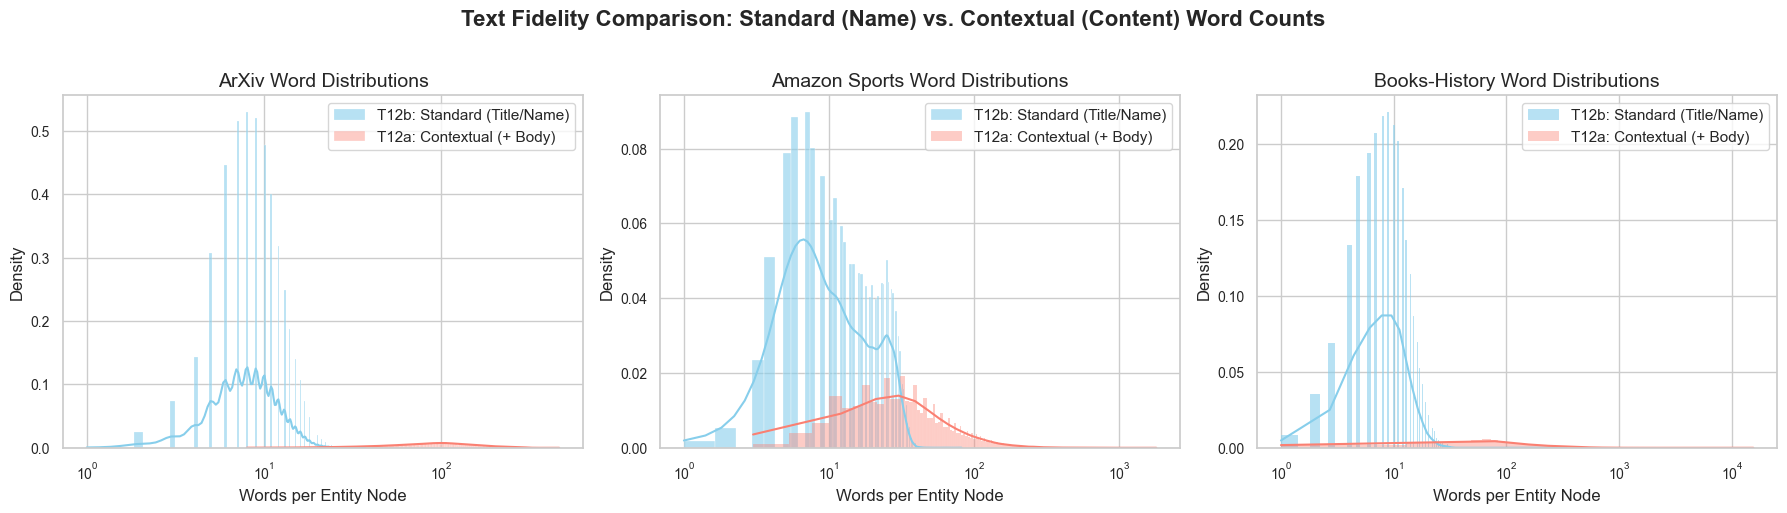

/var/folders/l7/ds3k084j4833xz000t7kjfdh0000gn/T/ipykernel_36432/2184015740.py:85: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=arxiv_cats.values, y=arxiv_cats.index, palette="viridis", ax=axes[0])
/var/folders/l7/ds3k084j4833xz000t7kjfdh0000gn/T/ipykernel_36432/2184015740.py:91: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=amazon_labels.index.map({1: 'Positive (≥4★)', 0: 'Negative (<4★)'}), y=amazon_labels.values, palette="vlag", ax=axes[1])
/var/folders/l7/ds3k084j4833xz000t7kjfdh0000gn/T/ipykernel_36432/2184015740.py:97: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` f

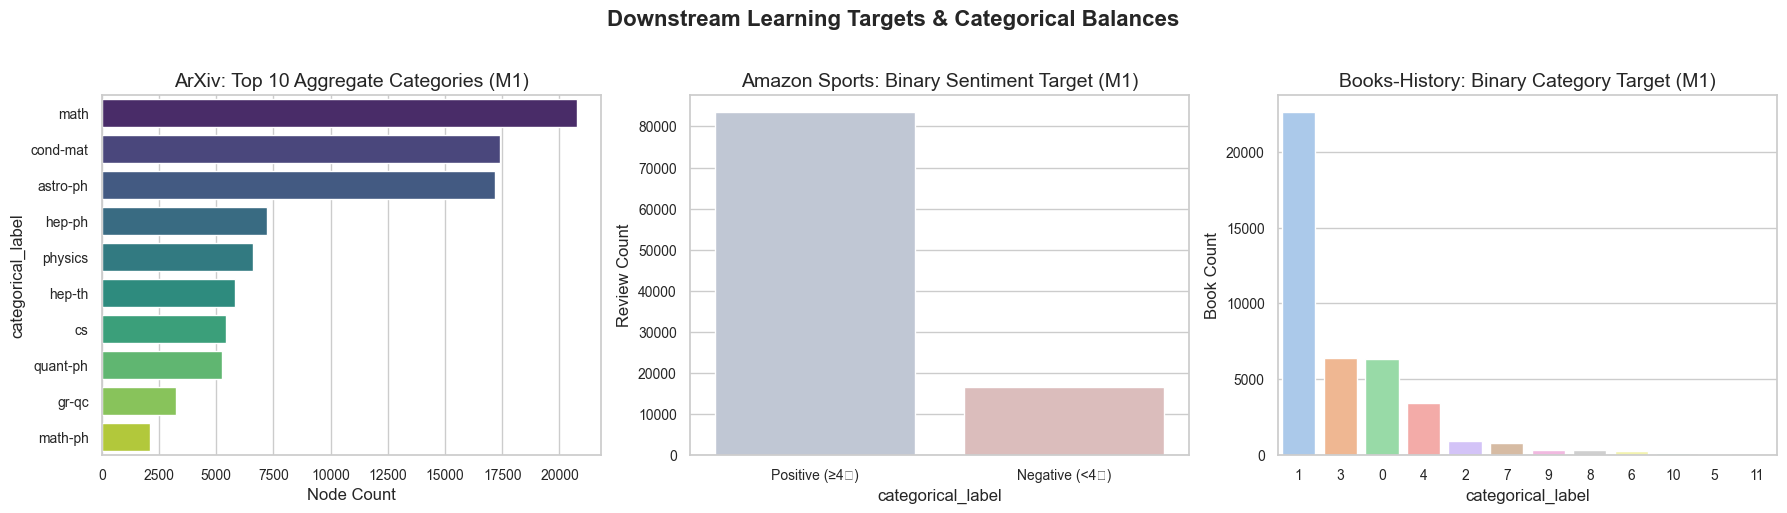

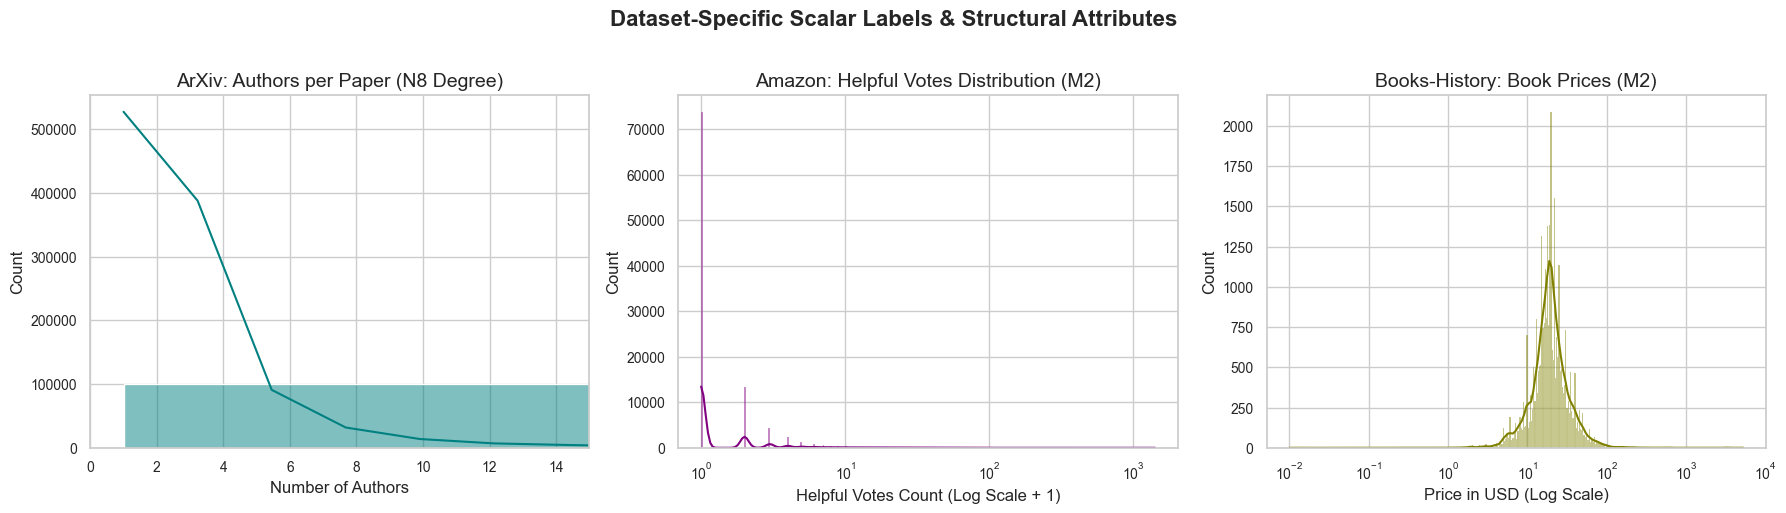

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic for presentation slides
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16
})

# 1. Reconstruct full datasets for holistic EDA
eda_datasets = {
    "ArXiv": pd.concat([arxiv_train, arxiv_test], ignore_index=True),
    "Amazon Sports": pd.concat([amazon_train, amazon_test], ignore_index=True),
    "Books-History": pd.concat([history_train, history_test], ignore_index=True)
}

# ==========================================
# PART 1: TEXTUAL SUMMARIES & SCHEMA CHECKS
# ==========================================
print("=" * 60)
print("       EXPLORATORY DATA ANALYSIS & SCHEMA SUMMARY")
print("=" * 60)

for name, df in eda_datasets.items():
    print(f"\n📊 DATASET: {name}")
    print(f"├── Total Rows: {len(df):,}")
    print(f"├── Generic Columns: {list(df.columns)}")
    
    # Calculate non-null counts for specific keys to verify data density
    print("└── Column Profiling:")
    for col in df.columns:
        non_null = df[col].notnull().sum()
        pct = (non_null / len(df)) * 100
        print(f"    • {col:<18} -> {non_null:>7,} valid rows ({pct:.1f}%)")
        
    print("\n🔹 Statistical Summary (pd.describe):")
    # Capture numeric or object summaries where applicable
    display(df.describe(include='all').dropna(how='all'))
    print("-" * 50)


# ==========================================
# PART 2: SLIDE VISUALIZATIONS
# ==========================================

# 📸 FIGURE 1: Text Fidelity Disparities (Contextual vs. Standard)
# Rationale for Slide: Visualizes why T12a (Contextual) contains vastly more graph information than T12b (Standard).
fig1, axes = plt.subplots(1, 3, figsize=(18, 5))
fig1.suptitle("Text Fidelity Comparison: Standard (Name) vs. Contextual (Content) Word Counts", weight='bold', y=1.02)

for ax, (name, df) in zip(axes, eda_datasets.items()):
    # Compute word counts for both fidelities, filtering out empty strings
    words_b = df['text_fidelity_b'].fillna('').apply(lambda x: len(str(x).split()) if str(x).strip() else 0)
    words_a = df['text_fidelity_a'].fillna('').apply(lambda x: len(str(x).split()) if str(x).strip() else 0)
    
    # Drop zeros for cleaner density plotting
    words_b = words_b[words_b > 0]
    words_a = words_a[words_a > 0]
    
    sns.histplot(words_b, color="skyblue", label="T12b: Standard (Title/Name)", kde=True, ax=ax, stat="density", common_norm=False, alpha=0.6)
    sns.histplot(words_a, color="salmon", label="T12a: Contextual (+ Body)", kde=True, ax=ax, stat="density", common_norm=False, alpha=0.4)
    
    ax.set_title(f"{name} Word Distributions")
    ax.set_xlabel("Words per Entity Node")
    ax.set_ylabel("Density")
    ax.set_xscale("log")  # Text data is naturally long-tailed
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


# 📸 FIGURE 2: Label & Category Distributions
# Rationale for Slide: Shows the target balance across all three downstream classification/graph tasks.
fig2, axes = plt.subplots(1, 3, figsize=(18, 5))
fig2.suptitle("Downstream Learning Targets & Categorical Balances", weight='bold', y=1.02)

# ArXiv: Top 10 categories
arxiv_cats = eda_datasets["ArXiv"]['categorical_label'].value_counts().head(10)
sns.barplot(x=arxiv_cats.values, y=arxiv_cats.index, palette="viridis", ax=axes[0])
axes[0].set_title("ArXiv: Top 10 Aggregate Categories (M1)")
axes[0].set_xlabel("Node Count")

# Amazon: Rating Target Balance
amazon_labels = eda_datasets["Amazon Sports"]['categorical_label'].value_counts()
sns.barplot(x=amazon_labels.index.map({1: 'Positive (≥4★)', 0: 'Negative (<4★)'}), y=amazon_labels.values, palette="vlag", ax=axes[1])
axes[1].set_title("Amazon Sports: Binary Sentiment Target (M1)")
axes[1].set_ylabel("Review Count")

# History: CS-TAG Target Balance
history_labels = eda_datasets["Books-History"]['categorical_label'].value_counts()
sns.barplot(x=history_labels.index.astype(str), y=history_labels.values, palette="pastel", ax=axes[2])
axes[2].set_title("Books-History: Binary Category Target (M1)")
axes[2].set_ylabel("Book Count")

plt.tight_layout()
plt.show()


# 📸 FIGURE 3: Metadata & Graph Structural Metrics
# Rationale for Slide: Explores the extra modalities available (Continuous labels, edge densities, structural traits).
fig3, axes = plt.subplots(1, 3, figsize=(18, 5))
fig3.suptitle("Dataset-Specific Scalar Labels & Structural Attributes", weight='bold', y=1.02)

# 1. ArXiv: Structural Multi-authorship (Secondary IDs per Primary ID)
author_counts = eda_datasets["ArXiv"]['secondary_id'].apply(lambda x: len(x) if isinstance(x, list) else 0)
sns.histplot(author_counts[author_counts > 0], bins=20, color="teal", ax=axes[0], kde=True)
axes[0].set_title("ArXiv: Authors per Paper (N8 Degree)")
axes[0].set_xlabel("Number of Authors")
axes[0].set_xlim(0, 15)

# 2. Amazon: Scalar Target (Helpful Votes) Log distribution
helpful_votes = pd.to_numeric(eda_datasets["Amazon Sports"]['scalar_label'], errors='coerce').dropna()
sns.histplot(helpful_votes + 1, log_scale=True, color="purple", ax=axes[1], kde=True) # +1 to safely log zero-votes
axes[1].set_title("Amazon: Helpful Votes Distribution (M2)")
axes[1].set_xlabel("Helpful Votes Count (Log Scale + 1)")

# 3. History: Book Price Log Distribution
prices = pd.to_numeric(eda_datasets["Books-History"]['scalar_label'], errors='coerce').dropna()
sns.histplot(prices[prices > 0], log_scale=True, color="olive", ax=axes[2], kde=True)
axes[2].set_title("Books-History: Book Prices (M2)")
axes[2].set_xlabel("Price in USD (Log Scale)")

plt.tight_layout()
plt.show()